1. Dosyayı Yükleme ve Sütun Analizi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1) Optimize edilmiş Parquet klasörünü yükle
print("Temizlenmiş veri klasörü yükleniyor, lütfen bekleyin...")
df = pd.read_parquet('../data/cleaned_parquets/')
df.columns = df.columns.str.strip()

# 2) Sütun analizi yap — shape, dtypes, null değerler
print("\n--- SÜTUN ANALİZİ ---")
print(f"Veri Seti Boyutu (Satır sayısı, Sütun sayısı): {df.shape}")
print("\nVeri Tiplerinin Dağılımı:")
print(df.dtypes.value_counts())
print(f"\nToplam Eksik (Null) Değer Sayısı: {df.isnull().sum().sum()}")

Temizlenmiş veri klasörü yükleniyor, lütfen bekleyin...

--- SÜTUN ANALİZİ ---
Veri Seti Boyutu (Satır sayısı, Sütun sayısı): (16233002, 78)

Veri Tiplerinin Dağılımı:
float32    77
str         1
Name: count, dtype: int64

Toplam Eksik (Null) Değer Sayısı: 64264


2. Hedef Değişken (Label) Dağılımı

--- SALDIRI TİPLERİ DAĞILIMI ---
Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Label                             59
Name: count, dtype: int64


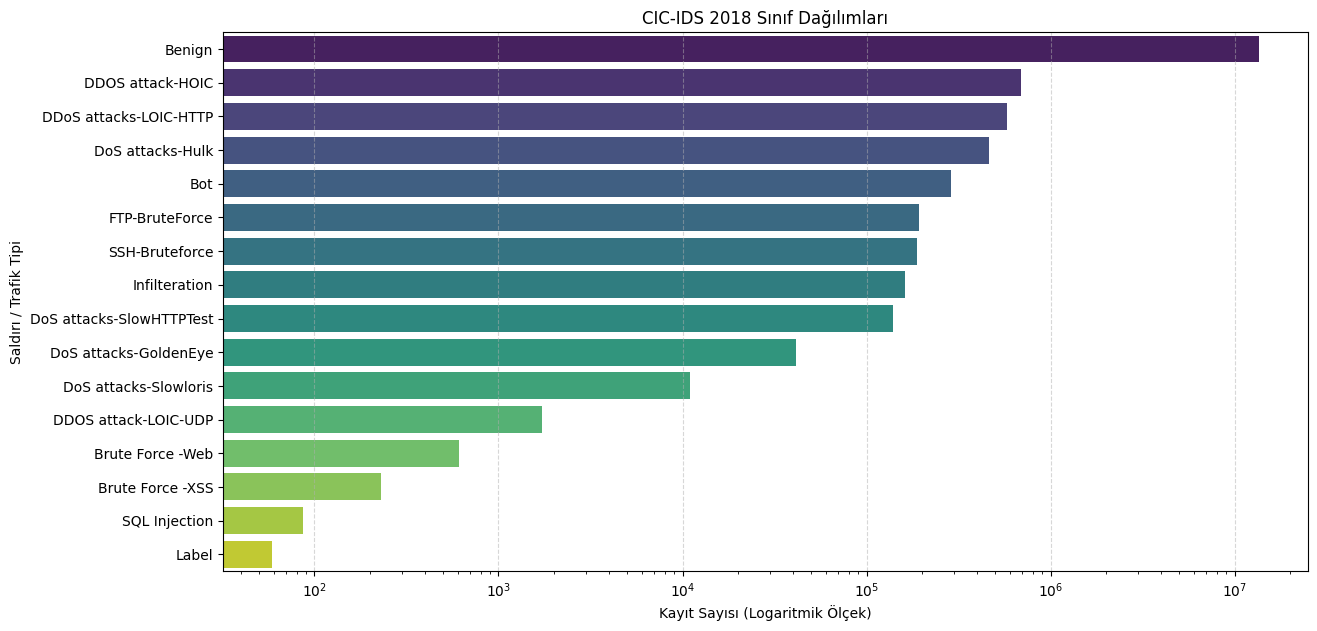

In [2]:
# 3) Label (hedef sütun) dağılımını incele
print("--- SALDIRI TİPLERİ DAĞILIMI ---")
label_counts = df['Label'].value_counts()
print(label_counts)

# Dağılımı grafik üzerinde görelim
plt.figure(figsize=(14, 7))
# Bazı saldırı sayıları çok az, bazıları çok fazla olduğu için grafiği logaritmik ölçekte çiziyoruz
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.title('CIC-IDS 2018 Sınıf Dağılımları')
plt.xlabel('Kayıt Sayısı (Logaritmik Ölçek)')
plt.ylabel('Saldırı / Trafik Tipi')
plt.xscale('log')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

3. Sonsuz (inf) ve NaN Değerlerin Kontrolü

In [3]:
# 4) Sonsuz (inf) ve NaN değerleri tespit et ve temizle
print("Eksik veya hatalı değerler doğrulanıyor...")

# Olası sonsuz değerleri NaN formatına çek
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Hangi sütunda ne kadar eksik değer var raporla
null_columns = df.isnull().sum()
print("\nEksik (NaN) Değer İçeren Sütunlar:")
print(null_columns[null_columns > 0])

# Varsa satırları tamamen temizle
df.dropna(inplace=True)
print(f"\nTemizlik sonrası güncel satır sayısı: {df.shape[0]}")

Eksik veya hatalı değerler doğrulanıyor...

Eksik (NaN) Değer İçeren Sütunlar:
Protocol           59
Flow Duration      59
Tot Fwd Pkts       59
Tot Bwd Pkts       59
TotLen Fwd Pkts    59
                   ..
Active Min         59
Idle Mean          59
Idle Std           59
Idle Max           59
Idle Min           59
Length: 77, dtype: int64

Temizlik sonrası güncel satır sayısı: 16137183


4. Sayısal Olmayan Sütunların Yönetimi

In [4]:
# 5) Sayısal olmayan sütunları düşür veya encode et
print("Sayısal formatta olmayan sütunlar aranıyor...")
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Tespit edilen sütunlar: {non_numeric_cols}")

# 'Label' dışındaki metinsel sütunları temizle (Zaten ilk başta çoğunu elemiştik)
cols_to_remove = [col for col in non_numeric_cols if col != 'Label']

if cols_to_remove:
    df.drop(columns=cols_to_remove, inplace=True)
    print(f"Güvenlik amacıyla şu sütunlar kaldırıldı: {cols_to_remove}")
else:
    print("Harika! 'Label' hariç tüm özellikler zaten sayısal (XGBoost'a hazır) formatta.")

Sayısal formatta olmayan sütunlar aranıyor...
Tespit edilen sütunlar: ['Label']
Harika! 'Label' hariç tüm özellikler zaten sayısal (XGBoost'a hazır) formatta.


5. Korelasyon Analizi

Özellikler arası korelasyon hesaplanıyor (Bu işlem veri boyutundan dolayı 1-2 dakika sürebilir)...

Birbiriyle aşırı yüksek ilişkili (>0.95) sütun sayısı: 27
Elenebilecek özelliklere ilk 10 örnek: ['TotLen Bwd Pkts', 'Fwd Pkt Len Std', 'Bwd Pkt Len Std', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Fwd Header Len']


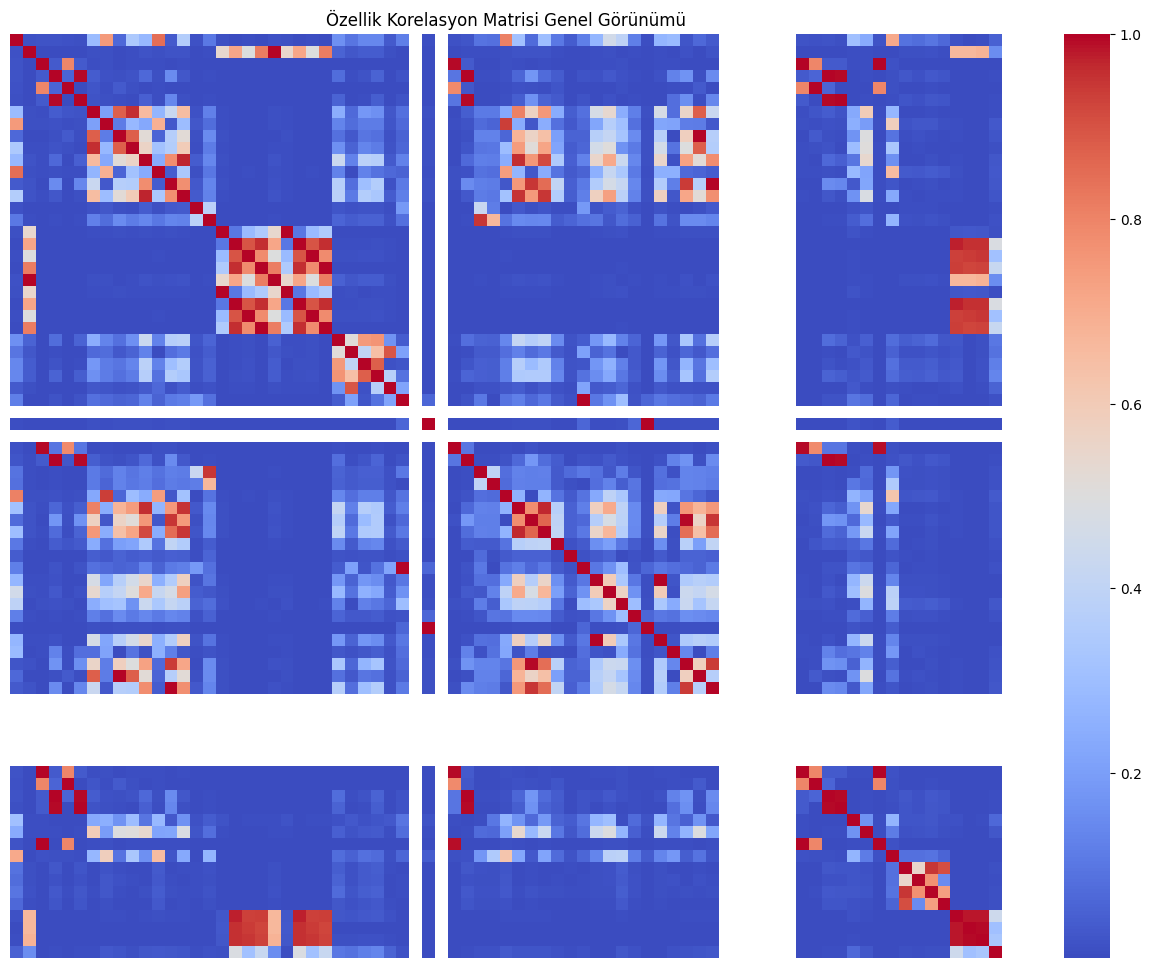

In [5]:
# 6) Korelasyon matrisi ile özellikler arası ilişkileri incele
print("Özellikler arası korelasyon hesaplanıyor (Bu işlem veri boyutundan dolayı 1-2 dakika sürebilir)...")

# Sadece girdi özelliklerini seçiyoruz (Label hariç)
features_df = df.select_dtypes(include=[np.number])
corr_matrix = features_df.corr().abs()

# Birbiriyle %95 ve üzeri korelasyona sahip (aynı bilgiyi taşıyan) sütunları yakala
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

print(f"\nBirbiriyle aşırı yüksek ilişkili (>0.95) sütun sayısı: {len(high_corr_features)}")
print("Elenebilecek özelliklere ilk 10 örnek:", high_corr_features[:10])

# Korelasyon Isı Haritası grafiği
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title('Özellik Korelasyon Matrisi Genel Görünümü')
plt.show()

In [6]:
import pandas as pd
import numpy as np
import glob
import gc
import os

# Temizlenmiş parquet dosyalarımızın listesini alıyoruz
parquet_files = glob.glob('../data/cleaned_parquets/*.parquet')

print("Parçalar teker teker okunuyor, detaylı temizlik yapılıyor ve üzerine yazılıyor...")

for i, file in enumerate(parquet_files):
    file_name = os.path.basename(file)
    print(f"[{i+1}/{len(parquet_files)}] İşleniyor: {file_name}")
    
    # 1. Sadece bir parçayı RAM'e al
    df = pd.read_parquet(file)
    ilk_satir = df.shape[0]
    
    # 2. Sonsuz (inf) ve NaN değerleri temizle
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    
    # 3. Kopya (Duplicate) satırları temizle
    df.drop_duplicates(inplace=True)
    
    # (Opsiyonel) Eğer EDA'da elediğin yüksek korelasyonlu sütunlar varsa 
    # onları da burada df.drop(columns=['sutun1', 'sutun2']) şeklinde silebilirsin.
    
    son_satir = df.shape[0]
    silinen = ilk_satir - son_satir
    
    # 4. Temizlenmiş veriyi KENDİ ÜZERİNE kaydet (Disk tasarrufu)
    df.to_parquet(file, index=False)
    
    print(f"  -> {silinen} hatalı/kopya satır silindi. Üzerine yazıldı.")
    
    # 5. RAM'i boşalt
    del df
    gc.collect()

print("\nTüm dosyalar kendi içlerinde temizlendi ve güncellendi! Veri setin artık XGBoost'a girmeye hazır.")

Parçalar teker teker okunuyor, detaylı temizlik yapılıyor ve üzerine yazılıyor...
[1/10] İşleniyor: part_0.parquet
  -> 429734 hatalı/kopya satır silindi. Üzerine yazıldı.
[2/10] İşleniyor: part_1.parquet
  -> 254469 hatalı/kopya satır silindi. Üzerine yazıldı.
[3/10] İşleniyor: part_2.parquet
  -> 456702 hatalı/kopya satır silindi. Üzerine yazıldı.
[4/10] İşleniyor: part_3.parquet
  -> 2522730 hatalı/kopya satır silindi. Üzerine yazıldı.
[5/10] İşleniyor: part_4.parquet
  -> 487184 hatalı/kopya satır silindi. Üzerine yazıldı.
[6/10] İşleniyor: part_5.parquet
  -> 220220 hatalı/kopya satır silindi. Üzerine yazıldı.
[7/10] İşleniyor: part_6.parquet
  -> 221637 hatalı/kopya satır silindi. Üzerine yazıldı.
[8/10] İşleniyor: part_7.parquet
  -> 264141 hatalı/kopya satır silindi. Üzerine yazıldı.
[9/10] İşleniyor: part_8.parquet
  -> 82068 hatalı/kopya satır silindi. Üzerine yazıldı.
[10/10] İşleniyor: part_9.parquet
  -> 277554 hatalı/kopya satır silindi. Üzerine yazıldı.

Tüm dosyalar ken